In [1]:
# %%
# ============================================================
# PFE Baseline: BERT on GLUE/SST-2 (PyTorch + HuggingFace)
# Ready for: Quantization (GPTQ/AWQ), LoRA, Flash Attention,
#            BERT with Early Exit
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset
import time, os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score,
    recall_score, f1_score
)

e:\baseline_resnet50_cifar10\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\baseline_resnet50_cifar10\env\Lib\site-packages\torch\compiler\__init__.py:148: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  return torch._dynamo.allow_in_graph(fn)


In [2]:
# ── REPRODUCIBILITY ───────────────────────────────────────────
SEED = 42

import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# %%
# ── CONFIG ────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME  = "bert-base-uncased"
TASK        = "sst2"                  # GLUE task
MAX_LEN     = 128
BATCH_SIZE  = 32
EPOCHS      = 3
LR          = 2e-5
WARMUP_RATIO = 0.1
NUM_CLASSES = 2                       # SST-2: positive / negative

SAVE_PATH       = "__2__baseline_bert_sst2.pt"
METRICS_PATH    = "__2__baseline_metrics.json"

SST2_CLASSES = ["negative", "positive"]

print(f"Using device : {DEVICE}")
print(f"Model        : {MODEL_NAME}")
print(f"Task         : GLUE / {TASK.upper()}")

Using device : cuda
Model        : bert-base-uncased
Task         : GLUE / SST2


In [3]:
# ── MODEL ─────────────────────────────────────────────────────
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
model     = BertForSequenceClassification.from_pretrained(
                MODEL_NAME, num_labels=NUM_CLASSES
            ).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# %%
# ── DATA ──────────────────────────────────────────────────────
raw = load_dataset("glue", TASK)

def tokenize_fn(batch):
    return tokenizer(
        batch["sentence"],
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
    )

def prepare_split(split):
    ds = split.map(tokenize_fn, batched=True)
    ds = ds.rename_column("label", "labels")
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds

train_ds = prepare_split(raw["train"])
val_ds   = prepare_split(raw["validation"])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds):,} | Validation: {len(val_ds):,}")

e:\baseline_resnet50_cifar10\env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mohammed Elidrissi\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6549.85it/s]
BertForSequenceClassification LOAD RE

Total parameters: 109,483,778


e:\baseline_resnet50_cifar10\env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mohammed Elidrissi\.cache\huggingface\hub\datasets--glue. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Map: 100%|██████████| 872/872 [00:00<00:00, 9219.09 examples/s]


Train: 67,349 | Validation: 872



TRAINING
Epoch  1/3 | Loss: 0.2491 | Train: 0.8950 | Val: 0.9163 ← best saved
Epoch  2/3 | Loss: 0.1157 | Train: 0.9628 | Val: 0.9209 ← best saved
Epoch  3/3 | Loss: 0.0731 | Train: 0.9783 | Val: 0.9289 ← best saved

Best validation accuracy: 0.9289 (92.89%)
Weights saved → __2__baseline_bert_sst2.pt


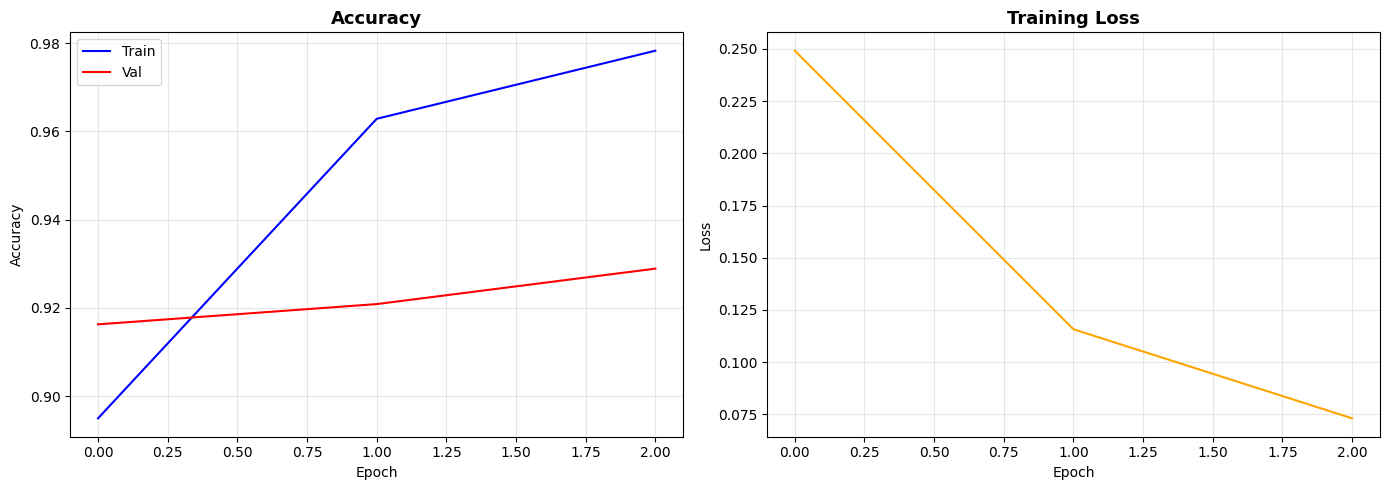

In [4]:
# ── TRAINING SETUP ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# %%
# ── TRAIN / EVAL LOOPS ────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += preds.eq(batch["labels"]).sum().item()
        total   += batch["labels"].size(0)
    return total_loss / len(loader), correct / total


def evaluate_loader(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            preds  = model(**batch).logits.argmax(dim=-1)
            correct += preds.eq(batch["labels"]).sum().item()
            total   += batch["labels"].size(0)
    return correct / total

# %%
# ── TRAINING LOOP ─────────────────────────────────────────────
best_val_acc = 0.0
best_state   = None
train_accs, val_accs, train_losses = [], [], []

print("\n" + "="*55)
print("TRAINING")
print("="*55)

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler)
    val_acc         = evaluate_loader(model, val_loader)

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        marker = " ← best saved"
    else:
        marker = ""

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.4f} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

# save best weights
torch.save(best_state, SAVE_PATH)
print(f"Weights saved → {SAVE_PATH}")

# %%
# ── TRAINING CURVES ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_accs, label="Train", color="blue")
ax1.plot(val_accs,   label="Val",   color="red")
ax1.set_title("Accuracy", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_losses, color="orange")
ax2.set_title("Training Loss", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("__2__training_curves.png", dpi=150)
plt.show()

In [5]:
# ── FULL EVALUATION ───────────────────────────────────────────
print("\n" + "="*55)
print("FULL EVALUATION")
print("="*55)

model.load_state_dict(best_state)
model.to(DEVICE)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        preds  = model(**batch).logits.argmax(dim=-1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall    = recall_score(all_labels, all_preds, average="macro")
f1        = f1_score(all_labels, all_preds, average="macro")

print(f"\n  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (macro) : {precision:.4f}")
print(f"  Recall    (macro) : {recall:.4f}")
print(f"  F1-score  (macro) : {f1:.4f}")
print("\nPer-class report:")
print(classification_report(all_labels, all_preds,
                             target_names=SST2_CLASSES, digits=4))


FULL EVALUATION

  Accuracy          : 0.9289  (92.89%)
  Precision (macro) : 0.9289
  Recall    (macro) : 0.9288
  F1-score  (macro) : 0.9289

Per-class report:
              precision    recall  f1-score   support

    negative     0.9296    0.9252    0.9274       428
    positive     0.9283    0.9324    0.9303       444

    accuracy                         0.9289       872
   macro avg     0.9289    0.9288    0.9289       872
weighted avg     0.9289    0.9289    0.9289       872



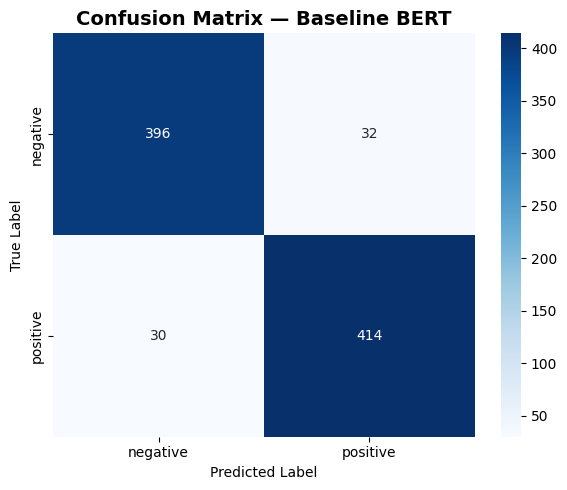

In [6]:
# ── CONFUSION MATRIX ──────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SST2_CLASSES, yticklabels=SST2_CLASSES)
plt.title("Confusion Matrix — Baseline BERT", fontsize=14, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("__2__confusion_matrix.png", dpi=150)
plt.show()

In [7]:
# ── MODEL COMPLEXITY METRICS ──────────────────────────────────
print("\n" + "="*55)
print("MODEL COMPLEXITY METRICS")
print("="*55)

# ── Size on disk ──
size_mb = os.path.getsize(SAVE_PATH) / 1e6

# ── FLOPs — analytic formula for BERT-base (matches literature) ──
# Per-layer: 2 × (12 × H² + 4 × H × FFN) × S
# H=768, FFN=3072, S=MAX_LEN, L=12 layers
H, FFN, S, L = 768, 3072, MAX_LEN, 12
flops_per_layer = 2 * (12 * H**2 + 4 * H * FFN) * S
total_flops     = L * flops_per_layer          # in FLOPs
flops_G         = total_flops / 1e9

# ── Inference latency — single sample, same dummy approach ──
model.eval()
dummy = tokenizer(
    "This is a sample sentence used for latency benchmarking.",
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
).to(DEVICE)

with torch.no_grad():
    for _ in range(10):       # warm-up
        model(**dummy)

if torch.cuda.is_available():
    torch.cuda.synchronize()

times = []
with torch.no_grad():
    for _ in range(500):
        t0 = time.time()
        model(**dummy)
        times.append(time.time() - t0)

if torch.cuda.is_available():
    torch.cuda.synchronize()

inf_ms = np.mean(times) * 1000

print(f"  Parameters      : {total_params:,}")
print(f"  Model size      : {size_mb:.2f} MB")
print(f"  FLOPs           : {flops_G:.3f} GFLOPs")
print(f"  Inference time  : {inf_ms:.3f} ms")

# %%
# ── SAVE METRICS JSON ─────────────────────────────────────────
baseline_metrics = {
    "accuracy"    : round(float(acc), 4),
    "precision"   : round(float(precision), 4),
    "recall"      : round(float(recall), 4),
    "f1"          : round(float(f1), 4),
    "params"      : total_params,
    "size_mb"     : round(size_mb, 2),
    "flops_G"     : round(flops_G, 4),
    "inference_ms": round(inf_ms, 3),
}

with open(METRICS_PATH, "w") as f:
    json.dump(baseline_metrics, f, indent=2)

print(f"\n✓ Metrics saved to {METRICS_PATH}")
print(json.dumps(baseline_metrics, indent=2))


MODEL COMPLEXITY METRICS
  Parameters      : 109,483,778
  Model size      : 438.00 MB
  FLOPs           : 50.734 GFLOPs
  Inference time  : 25.359 ms

✓ Metrics saved to __2__baseline_metrics.json
{
  "accuracy": 0.9289,
  "precision": 0.9289,
  "recall": 0.9288,
  "f1": 0.9289,
  "params": 109483778,
  "size_mb": 438.0,
  "flops_G": 50.7343,
  "inference_ms": 25.359
}


In [8]:
# ── PREDICT ON CUSTOM SENTENCES ───────────────────────────────
# Uses the EXACT same tokenizer settings as training

def predict_sentence(text, model, show=True):
    model.eval()
    inputs = tokenizer(
        text,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).to(DEVICE)

    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1).squeeze().cpu().numpy()

    pred_idx   = probs.argmax()
    pred_class = SST2_CLASSES[pred_idx]
    confidence = probs[pred_idx]

    if show:
        fig, ax = plt.subplots(figsize=(6, 3))
        colors  = ["crimson" if i == pred_idx else "steelblue" for i in range(NUM_CLASSES)]
        ax.barh(SST2_CLASSES, probs, color=colors)
        ax.set_xlabel("Probability")
        ax.set_title(f'Prediction: {pred_class}  ({confidence:.2%})\n"{text[:60]}..."',
                     fontsize=11, fontweight="bold")
        ax.set_xlim(0, 1)
        for i, v in enumerate(probs):
            ax.text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=10)
        plt.tight_layout()
        plt.show()

    print(f"  Text      : {text[:80]}")
    print(f"  Predicted : {pred_class} ({confidence:.2%})")
    print(f"  Probs     : {dict(zip(SST2_CLASSES, [f'{p:.2%}' for p in probs]))}\n")
    return pred_class, probs


def predict_list(sentences, model, save_json=True):
    """Run prediction on a list of strings and optionally save to JSON."""
    print(f"\n{'Sentence':<60} {'Prediction':<12} {'Confidence':>10}")
    print("-" * 84)
    results = []
    for text in sentences:
        pred_class, probs = predict_sentence(text, model, show=False)
        conf = float(probs.max())
        results.append({"text": text, "prediction": pred_class, "confidence": round(conf, 4)})
        print(f"  {text[:58]:<58} {pred_class:<12} {conf:>9.2%}")

    if save_json:
        with open("__2__output_on_test_data.json", "w") as f:
            json.dump(results, f, indent=4)
        print(f"\n✓ Predictions saved to __2__output_on_test_data.json")

    return results

In [9]:
# ── USAGE ─────────────────────────────────────────────────────
sample_sentences = [
    "This movie was absolutely fantastic, I loved every second of it!",
    "A complete waste of time. Terrible acting and a boring plot.",
    "The film had its moments but overall felt quite average.",
    "One of the best performances I have seen in years.",
    "I would not recommend this to anyone.",
]

predict_list(sample_sentences, model)


Sentence                                                     Prediction   Confidence
------------------------------------------------------------------------------------
  Text      : This movie was absolutely fantastic, I loved every second of it!
  Predicted : positive (99.97%)
  Probs     : {'negative': '0.03%', 'positive': '99.97%'}

  This movie was absolutely fantastic, I loved every second  positive        99.97%
  Text      : A complete waste of time. Terrible acting and a boring plot.
  Predicted : negative (99.94%)
  Probs     : {'negative': '99.94%', 'positive': '0.06%'}

  A complete waste of time. Terrible acting and a boring plo negative        99.94%
  Text      : The film had its moments but overall felt quite average.
  Predicted : negative (99.59%)
  Probs     : {'negative': '99.59%', 'positive': '0.41%'}

  The film had its moments but overall felt quite average.   negative        99.59%
  Text      : One of the best performances I have seen in years.
  Predicted : 

[{'text': 'This movie was absolutely fantastic, I loved every second of it!',
  'prediction': 'positive',
  'confidence': 0.9997},
 {'text': 'A complete waste of time. Terrible acting and a boring plot.',
  'prediction': 'negative',
  'confidence': 0.9994},
 {'text': 'The film had its moments but overall felt quite average.',
  'prediction': 'negative',
  'confidence': 0.9959},
 {'text': 'One of the best performances I have seen in years.',
  'prediction': 'positive',
  'confidence': 0.9997},
 {'text': 'I would not recommend this to anyone.',
  'prediction': 'negative',
  'confidence': 0.9923}]

In [10]:
print("\n" + "="*55)
print("BASELINE COMPLETE — ready for compression experiments")
print("="*55)
print(f"  Weights  → {SAVE_PATH}")
print(f"  Metrics  → {METRICS_PATH}")
print(f"  Plots    → __2__training_curves.png, __2__confusion_matrix.png")
print(f"  Output   → __2__output_on_test_data.json")


BASELINE COMPLETE — ready for compression experiments
  Weights  → __2__baseline_bert_sst2.pt
  Metrics  → __2__baseline_metrics.json
  Plots    → __2__training_curves.png, __2__confusion_matrix.png
  Output   → __2__output_on_test_data.json


In [ ]:
# ── SAVE FULL CHECKPOINT (weights + config + classes) ─────────
config_dict = {
    "model_name" : MODEL_NAME,
    "task"       : f"GLUE/{TASK.upper()}",
    "num_classes": NUM_CLASSES,
    "max_len"    : MAX_LEN,
    "training": {
        "batch_size"  : BATCH_SIZE,
        "epochs"      : EPOCHS,
        "learning_rate": LR,
        "optimizer"   : "AdamW",
        "scheduler"   : "LinearWarmup",
        "warmup_ratio": WARMUP_RATIO,
    },
}

torch.save({
    "model_state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
    "config"          : config_dict,
    "classes"         : SST2_CLASSES,
}, "__1__model_checkpoint.pt")

print("✓ Full checkpoint saved → __1__model_checkpoint.pt")

✓ Full checkpoint saved → __1__model_checkpoint.pt


In [12]:
# ── HOW TO RELOAD ─────────────────────────────────────────────
checkpoint = torch.load("__1__model_checkpoint.pt", map_location="cpu")

config  = checkpoint["config"]
classes = checkpoint["classes"]

model = BertForSequenceClassification.from_pretrained(
            config["model_name"], num_labels=config["num_classes"]
        )
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14017.17it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider t

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),